# Classificação de Estados de Estresse na Matriz Energética no subsistema Nordeste: Um Estudo Comparativo com Machine Learning
##### Vitória Emanuele e Julia Gabriele



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## 1. Dataset:

A base de dados foi estruturada a partir da consolidação de datasets anuais disponibilizados pelo Operador Nacional do Sistema Elétrico (ONS). Cada arquivo original compreende o balanço energético de um ano específico, com os dados segmentados por subsistemas regionais e registrados em granularidade horária. Para esta análise, foram integrados os registros referentes ao período de 2020 a 2025.

### 1.1 Dicionário de Variáveis (Dataset ONS):

1. Identificação e Tempo
*   **`id_subsistema` / `nom_subsistema`**: Identificam o bloco geográfico analisado (ex: Nordeste). Os valores agregam toda a geração e consumo dos estados que compõem essa região como um sistema único.
*   **`din_instante`**: A marca temporal (data e hora) em que a medição da rede foi registrada.

2. A Oferta (Matriz de Geração em MWmed)
*   **`val_gerhidraulica` (Hídrica)**: Total de energia gerada por represas e usinas hidrelétricas. 
*   **`val_gereolica` (Eólica)**: Potência gerada pela força dos ventos. 
*   **`val_gersolar` (Fotovoltaica)**: Geração solar da região. 
*   **`val_gertermica` (Térmica)**: Energia gerada pela queima de combustíveis (fósseis/biomassa). 

3. A Demanda
*   **`val_carga` (Carga/Consumo)**: Representa o consumo total de energia de toda a região (residências, indústrias, iluminação pública). É a linha de demanda que o sistema elétrico precisa obrigatoriamente atender a cada instante para evitar um apagão.

4. O Balanço (Variável Alvo)
*   **`val_intercambio` (Saldo Líquido)**: Representa o saldo da balança comercial de energia da região com o restante do país. 
    *   **Valores Positivos (+)** indicam sobrecarga de geração regional (a região gerou mais do que consumiu e está exportando o excedente). 
    *   **Valores Negativos (-)** indicam déficit (a região consumiu mais do que gerou e precisou importar energia de outros subsistemas para não colapsar).



### 1.2 Pré processamento:
- As bases de dados foram concatenadas em um único dataset unificado, garantindo a continuidade da série temporal;
- Filtrou o subsistema Nordeste;
- Conversão da coluna `din_instante` para o formato *datetime*.

In [2]:
df_2020 = pd.read_csv('./datasets/BALANCO_ENERGIA_SUBSISTEMA_2020.csv', sep=';')

In [3]:
df_2021 = pd.read_csv('./datasets/BALANCO_ENERGIA_SUBSISTEMA_2021.csv', sep=';')

In [4]:
df_2022 = pd.read_csv('./datasets/BALANCO_ENERGIA_SUBSISTEMA_2022.csv', sep=';')

In [5]:
df_2023 = pd.read_csv('./datasets/BALANCO_ENERGIA_SUBSISTEMA_2023.csv', sep=';')

In [6]:
df_2024 = pd.read_csv('./datasets/BALANCO_ENERGIA_SUBSISTEMA_2024.csv', sep=';')

In [7]:
df_2025 = pd.read_csv('./datasets/BALANCO_ENERGIA_SUBSISTEMA_2025.csv', sep=';')

In [8]:
df = pd.concat([df_2020, df_2021, df_2022, df_2023, df_2024, df_2025], ignore_index=True)

column_info = pd.DataFrame({
    'Column Name': df.columns,
    'Data Type': df.dtypes,
    'Non-Null Count': df.count(),
})

display(column_info.reset_index(drop=True))

,Column Name,Data Type,Non-Null Count
0,id_subsistema,str,263040
1,nom_subsistema,str,263040
2,din_instante,str,263040
3,val_gerhidraulica,float64,263040
4,val_gertermica,float64,263040
5,val_gereolica,float64,263040
6,val_gersolar,float64,263040
7,val_carga,float64,263040
8,val_intercambio,float64,263040


In [9]:
df_ne = df[df['nom_subsistema'] == 'NORDESTE'].copy()

column_info = pd.DataFrame({
    'Column Name': df_ne.columns,
    'Data Type': df_ne.dtypes,
    'Non-Null Count': df_ne.count(),
})

display(column_info.reset_index(drop=True))

,Column Name,Data Type,Non-Null Count
0,id_subsistema,str,52608
1,nom_subsistema,str,52608
2,din_instante,str,52608
3,val_gerhidraulica,float64,52608
4,val_gertermica,float64,52608
5,val_gereolica,float64,52608
6,val_gersolar,float64,52608
7,val_carga,float64,52608
8,val_intercambio,float64,52608


In [10]:
df_ne['din_instante'] = pd.to_datetime(df['din_instante'])

column_info = pd.DataFrame({
    'Column Name': df_ne.columns,
    'Data Type': df_ne.dtypes,
    'Non-Null Count': df_ne.count(),
})

display(column_info.reset_index(drop=True))

,Column Name,Data Type,Non-Null Count
0,id_subsistema,str,52608
1,nom_subsistema,str,52608
2,din_instante,datetime64[us],52608
3,val_gerhidraulica,float64,52608
4,val_gertermica,float64,52608
5,val_gereolica,float64,52608
6,val_gersolar,float64,52608
7,val_carga,float64,52608
8,val_intercambio,float64,52608


In [11]:
df_ne['data'] = df_ne['din_instante'].dt.date

## 2. Engenharia de atributos:

Embora a natureza da informação seja uma série temporal, a metodologia escolhida foi remover a dependência sequencial direta do tempo para treinar modelos estáticos de classificação (como Redes Neurais Artificiais, Árvores de Decisão e SVM) com base no resumo estatístico diário do comportamento da rede: 
- Usamos agrupamento por data para calcularmos as metricas das variaveis;
- A matriz de atributos `X` foi definida a partir das metricas calculadas, sendo composta por 23 parametros.
- Definimos a variavel alvo `y`a partir da variavel `val_intercambio`

Aplicação de metricas para as variaveis:
- carga (a demanda que o sistema precisa antender): média diaria, desvio padrão, maximo, minimo, assimetria/obliquidade (para identificar se o consumo ficou muito concentrado em apenas um periodo do dia.), Curtose (fundamental para detectar anomalias. uma alta curtosa indica um salto muito abrupto e anomalia de consumo em uma hora especifica).
- geração solar: média diaria, desvio padrão, maximo.
- geração eólica: média diaria, desvio padrão, maximo, minimo, assimetria(indica se o vento soprou mais forte apenas de manha ou apenas de noite), curtose (se houver uma rajada de um vento muito forte e isolado que gerou um pico repentino de energia).
- geração hidraulica: media diaria, desvio padrão, maximo, minimo.
- geração térmica: média diaria, desvio padrão, maximo, curtose.

### 2.1 Metricas:

In [12]:
df_carga = df_ne.groupby('data')['val_carga'].agg(
    carga_media='mean',
    carga_desvio='std',
    carga_maxima='max',
    carga_minima='min',
    carga_assimetria='skew',
    carga_curtose=pd.Series.kurt
)

In [13]:
df_eolica = df_ne.groupby('data')['val_gereolica'].agg(
    eolica_media='mean',
    eolica_desvio='std',
    eolica_maxima='max',
    eolica_minima='min',
    eolica_assimetria='skew',
    eolica_curtose=pd.Series.kurt
)

In [14]:
df_solar = df_ne.groupby('data')['val_gersolar'].agg(
    solar_media='mean',
    solar_desvio='std',
    solar_maxima='max'
)


In [15]:
df_hidraulica = df_ne.groupby('data')['val_gerhidraulica'].agg(
    hidraulica_media='mean',
    hidraulica_desvio='std',
    hidraulica_maxima='max',
    hidraulica_minima='min'
)

In [16]:
df_termica = df_ne.groupby('data')['val_gertermica'].agg(
    termica_media='mean',
    termica_desvio='std',
    termica_maxima='max',
    termica_curtose=pd.Series.kurt
)


### 2.2 Definição de X e alvo (y):

- A coluna `val_intercambio`: Calculamos o Desvio Padrão (desvio_global), que é o quanto esse saldo costuma oscilar em dias normais. Ao somar e subtrair 1 desvio padrão da média, é o "teto" (limite_superior) e o "piso" (limite_inferior). Qualquer valor que fique dentro dessa faixa é considerado a operação normal e segura do Sistema Interligado Nacional (SIN). É atraves dela que definimos a variavel alvo `y`.

- A matriz de atributos X é composta por 23 features ($p=23$), as metricas que tiramos de carga e gerações.

In [17]:
y = df_ne.groupby('data')['val_intercambio'].mean()

limite_sup = y.mean() + y.std()
limite_inf = y.mean() - y.std()

y = ((y > limite_sup) | (y < limite_inf)).astype(int).rename('y')

In [18]:
df = pd.concat([
    df_carga, 
    df_eolica, 
    df_solar, 
    df_hidraulica, 
    df_termica, 
    y
], axis=1)

In [19]:
X = df.drop(columns=['y'])

y = df['y']
y.value_counts()

y
0    1424
1     768
Name: count, dtype: int64

## 2. Separação dos dados em treino e teste:

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)


In [22]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 3. Arquitetura, treinamento e avaliação da rede neural artificial:

### 3.1 Calcular a dimensão VC :

Sabendo que temos $p=23$ e $N = 1753$

In [23]:
import math

N_treino = len(X_train_scaled)            

d_VC_max = N_treino / 10

h_max_real = (d_VC_max - 1) / (23 + 2)
h_max = math.ceil(h_max_real)

print(f"Número de amostras (N): {N_treino}")
print(f"Dimensão VC máxima permitida (d_VC): {d_VC_max:.2f}") 
print(f"Valor real de h_max: {h_max_real:.4f}")

Número de amostras (N): 1753
Dimensão VC máxima permitida (d_VC): 175.30
Valor real de h_max: 6.9720


### 3.2 Criando a rede:

In [24]:
from keras.models import Sequential
from keras.layers import Dense, Input

model = Sequential()
model.add(Input(shape=(23,))) 

model.add(Dense(7, kernel_initializer='normal', activation='relu'))
model.add(Dense(1, kernel_initializer='normal', activation='sigmoid'))

In [25]:
initial_weights = model.get_weights() 

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
print(model.summary()) 

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 7)              │           168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 176 (704.00 B)

 Trainable params: 176 (704.00 B)

 Non-trainable params: 0 (0.00 B)

None


### 3.3 Teste de Batch Size

In [26]:
from keras.callbacks import EarlyStopping

callback = EarlyStopping(
    monitor='val_loss', 
    patience=10,        
    restore_best_weights=True 
)

for batch in [8, 16, 32, 64]:
    print(f"Testando Batch Size: {batch}")
    model.set_weights(initial_weights)
    history = model.fit(
        X_train_scaled, y_train,
        validation_split=0.2, 
        epochs=200,          
        batch_size=batch,
        callbacks=[callback], 
        verbose=0
    )
    print(f"Treinamento parado na época: {len(history.history['loss'])}")
    print(f"Melhor Eout encontrado: {min(history.history['val_loss']):.4f}\n")

Testando Batch Size: 8
Treinamento parado na época: 103
Melhor Eout encontrado: 0.0976

Testando Batch Size: 16
Treinamento parado na época: 10
Melhor Eout encontrado: 0.5803

Testando Batch Size: 32
Treinamento parado na época: 10
Melhor Eout encontrado: 0.6173

Testando Batch Size: 64
Treinamento parado na época: 10
Melhor Eout encontrado: 0.6485



### Verficando Overfitting:

Epoch 1/200
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6384 - loss: 0.6767 - val_accuracy: 0.6695 - val_loss: 0.6573
Epoch 2/200
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6448 - loss: 0.6381 - val_accuracy: 0.6695 - val_loss: 0.6146
Epoch 3/200
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6448 - loss: 0.6040 - val_accuracy: 0.6695 - val_loss: 0.5858
Epoch 4/200
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7290 - loss: 0.5702 - val_accuracy: 0.8433 - val_loss: 0.5453
Epoch 5/200
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8638 - loss: 0.5079 - val_accuracy: 0.8348 - val_loss: 0.4877
Epoch 6/200
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8745 - loss: 0.4387 - val_accuracy: 0.8860 - val_loss: 0.4241
Epoch 7/200
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8930 - loss: 0.3759 - val_accuracy: 0.9031 - val_loss: 0.3700
Epoch 8/200
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9051 - loss: 0.3279 - val_accu

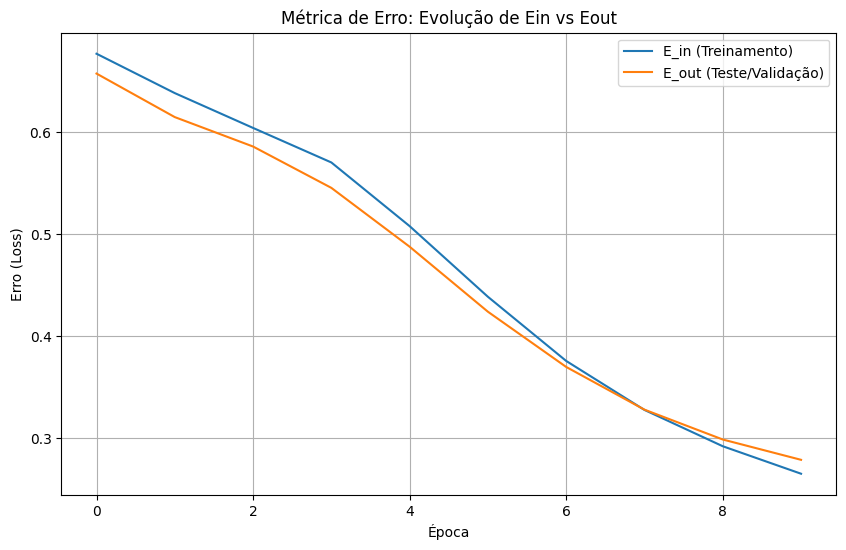

Erro de Treinamento (Ein): 0.6586
Erro de Teste (Eout): 0.6597
Acurácia Final (Teste): 0.6492


In [27]:
model.set_weights(initial_weights)

history = model.fit(
    X_train_scaled, y_train, 
    validation_split= 0.2,
    epochs=200, 
    batch_size=8, 
    callbacks=[callback],  
    verbose=1
)


plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='E_in (Treinamento)')
plt.plot(history.history['val_loss'], label='E_out (Teste/Validação)')
plt.title('Métrica de Erro: Evolução de Ein vs Eout')
plt.ylabel('Erro (Loss)')
plt.xlabel('Época')
plt.legend()
plt.grid(True)
plt.show()

ein, acc_train = model.evaluate(X_train_scaled, y_train, verbose=0)
eout, acc_test = model.evaluate(X_test_scaled, y_test, verbose=0)

print(f"Erro de Treinamento (Ein): {ein:.4f}") 
print(f"Erro de Teste (Eout): {eout:.4f}")
print(f"Acurácia Final (Teste): {acc_test:.4f}")

In [28]:
from sklearn.metrics import classification_report, accuracy_score

y_pred_prob = model.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.5).astype(int)

print("=== Métricas de Qualidade (Rede Neural) ===")
print(f"Acurácia: {accuracy_score(y_test, y_pred):.4f}\n")
print(classification_report(y_test, y_pred, target_names=['Normal (0)', 'Estresse (1)']))

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
=== Métricas de Qualidade (Rede Neural) ===
Acurácia: 0.6492

              precision    recall  f1-score   support

  Normal (0)       0.65      1.00      0.79       285
Estresse (1)       0.00      0.00      0.00       154

    accuracy                           0.65       439
   macro avg       0.32      0.50      0.39       439
weighted avg       0.42      0.65      0.51       439



c:\Users\Vitoria\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Vitoria\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Vitoria\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

### 3.4 Tratando :

#### 3.4.1 Grid Search Manual:

In [29]:
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras import regularizers
from keras.callbacks import EarlyStopping

In [30]:
taxas_dropout = [0.1, 0.2, 0.3]
taxas_l2 = [0.001, 0.01, 0.1]

melhor_val_loss = float('inf')
melhor_combinacao = {}

print("Iniciando Grid Search Manual...\n")

for drop in taxas_dropout:
    for l2_val in taxas_l2:
        print(f"Testando -> Dropout: {drop} | L2: {l2_val}")
        
        model = Sequential()
        
        model.add(Input(shape=(23,)))
        model.add(Dense(7, kernel_initializer='normal', 
                        kernel_regularizer=regularizers.l2(l2_val), 
                        activation='relu'))
        
        model.add(Dropout(drop))
        
        model.add(Dense(1, kernel_initializer='normal', activation='sigmoid'))
        
        model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
        
        es = EarlyStopping(monitor='val_loss', mode='min', verbose=0, patience=10, restore_best_weights=True)
        
        history = model.fit(X_train_scaled, y_train, 
                            validation_split=0.2, 
                            epochs=200, 
                            batch_size=8, 
                            callbacks=[es], 
                            verbose=0)
        
        min_val_loss = min(history.history['val_loss'])
        epoca_parada = len(history.history['loss'])
        
        print(f"   Parou na época: {epoca_parada} | Melhor Eout (val_loss): {min_val_loss:.4f}\n")
        
        if min_val_loss < melhor_val_loss:
            melhor_val_loss = min_val_loss
            melhor_combinacao = {
                'dropout': drop,
                'l2': l2_val,
                'epoca_parada': epoca_parada
            }

print("================ RESULTADO DO GRID SEARCH ================")
print(f"Melhor Eout (val_loss): {melhor_val_loss:.4f}")
print(f"Melhor Dropout: {melhor_combinacao['dropout']}")
print(f"Melhor L2: {melhor_combinacao['l2']}")

Iniciando Grid Search Manual...

Testando -> Dropout: 0.1 | L2: 0.001
   Parou na época: 133 | Melhor Eout (val_loss): 0.1015

Testando -> Dropout: 0.1 | L2: 0.01
   Parou na época: 120 | Melhor Eout (val_loss): 0.1940

Testando -> Dropout: 0.1 | L2: 0.1
   Parou na época: 194 | Melhor Eout (val_loss): 0.2998

Testando -> Dropout: 0.2 | L2: 0.001
   Parou na época: 127 | Melhor Eout (val_loss): 0.1237

Testando -> Dropout: 0.2 | L2: 0.01
   Parou na época: 157 | Melhor Eout (val_loss): 0.1307

Testando -> Dropout: 0.2 | L2: 0.1
   Parou na época: 46 | Melhor Eout (val_loss): 0.5751

Testando -> Dropout: 0.3 | L2: 0.001
   Parou na época: 111 | Melhor Eout (val_loss): 0.2557

Testando -> Dropout: 0.3 | L2: 0.01
   Parou na época: 114 | Melhor Eout (val_loss): 0.2614

Testando -> Dropout: 0.3 | L2: 0.1
   Parou na época: 133 | Melhor Eout (val_loss): 0.2517

================ RESULTADO DO GRID SEARCH ================
Melhor Eout (val_loss): 0.1015
Melhor Dropout: 0.1
Melhor L2: 0.001


#### 3.4.2 Validação (K-Fold Cross Validation):

In [31]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracies_train = []
accuracies_val = []

print("================ K-FOLD COM OS MELHORES PARÂMETROS ================")

i = 1
for train_index, val_index in skf.split(X_train_scaled, y_train):
    print(f"\n--- Treinando Fold {i} ---")
    
    X_train_fold, X_val_fold = X_train_scaled[train_index], X_train_scaled[val_index]
    
    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index] 
    
    model = Sequential()
    
    model.add(Dense(7, input_dim=23, kernel_initializer='normal', 
                    kernel_regularizer=regularizers.l2(0.001), activation='relu'))
    
    model.add(Dropout(0.1))
    
    model.add(Dense(1, kernel_initializer='normal', activation='sigmoid'))
    
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    
    es = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=10, restore_best_weights=True)
    
    history = model.fit(X_train_fold, y_train_fold, 
                        validation_data=(X_val_fold, y_val_fold), 
                        epochs=200, 
                        batch_size=8, 
                        callbacks=[es], 
                        verbose=0) 
                        
    E_in, accuracy_train = model.evaluate(X_train_fold, y_train_fold, batch_size=8, verbose=0)
    E_val, accuracy_val = model.evaluate(X_val_fold, y_val_fold, batch_size=8, verbose=0)
    
    accuracies_train.append(accuracy_train)
    accuracies_val.append(accuracy_val)
    
    print(f'Acurácia (treino): {accuracy_train:.4f}')
    print(f'Acurácia (validação): {accuracy_val:.4f}')
    print(f'Diferença (Treino - Validação): {accuracy_train - accuracy_val:.4f}')
    
    i += 1

avg_accuracy_train = np.mean(accuracies_train)
avg_accuracy_val = np.mean(accuracies_val)

print("\n================ Resumo Definitivo do K-Fold ================")
print(f"Média Acurácia Treino: {avg_accuracy_train:.4f}")
print(f"Média Acurácia Validação: {avg_accuracy_val:.4f}")

================ K-FOLD COM OS MELHORES PARÂMETROS ================

--- Treinando Fold 1 ---


c:\Users\Vitoria\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 104: early stopping
Restoring model weights from the end of the best epoch: 94.
Acurácia (treino): 0.9864
Acurácia (validação): 0.9744
Diferença (Treino - Validação): 0.0121

--- Treinando Fold 2 ---
Epoch 179: early stopping
Restoring model weights from the end of the best epoch: 169.
Acurácia (treino): 0.9843
Acurácia (validação): 0.9943
Diferença (Treino - Validação): -0.0100

--- Treinando Fold 3 ---
Epoch 159: early stopping
Restoring model weights from the end of the best epoch: 149.
Acurácia (treino): 0.9586
Acurácia (validação): 0.9487
Diferença (Treino - Validação): 0.0099

--- Treinando Fold 4 ---
Epoch 137: early stopping
Restoring model weights from the end of the best epoch: 127.
Acurácia (treino): 0.9865
Acurácia (validação): 0.9800
Diferença (Treino - Validação): 0.0065

--- Treinando Fold 5 ---
Epoch 193: early stopping
Restoring model weights from the end of the best epoch: 183.
Acurácia (treino): 0.9758
Acurácia (validação): 0.9686
Diferença (Treino - Validação)

In [32]:
from sklearn.metrics import classification_report, accuracy_score

print("Treinando o Modelo Definitivo Final...\n")

model_final = Sequential()
model_final.add(Dense(7, input_dim=23, kernel_initializer='normal', 
                      kernel_regularizer=regularizers.l2(0.001), activation='relu'))
model_final.add(Dropout(0.1))
model_final.add(Dense(1, kernel_initializer='normal', activation='sigmoid'))

model_final.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

es_final = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=10, restore_best_weights=True)

history_final = model_final.fit(X_train_scaled, y_train, 
                                validation_split=0.2, 
                                epochs=200, 
                                batch_size=8, 
                                callbacks=[es_final], 
                                verbose=1)


eout, acc_test = model_final.evaluate(X_test_scaled, y_test, batch_size=8, verbose=0)
print(f"Erro de Teste (E_out): {eout:.4f}")
print(f"Acurácia Final de Teste: {acc_test:.4f}\n")

y_pred_prob = model_final.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.5).astype(int)

print("--- Relatório de Classificação ---")
print(classification_report(y_test, y_pred, target_names=['Normal (0)', 'Estresse (1)']))

Treinando o Modelo Definitivo Final...

Epoch 1/200
176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6427 - loss: 0.6696 - val_accuracy: 0.7037 - val_loss: 0.6347
Epoch 2/200
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7660 - loss: 0.5936 - val_accuracy: 0.8262 - val_loss: 0.5571
Epoch 3/200
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8260 - loss: 0.5197 - val_accuracy: 0.8376 - val_loss: 0.4956
Epoch 4/200
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8566 - loss: 0.4610 - val_accuracy: 0.8632 - val_loss: 0.4407
Epoch 5/200
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8595 - loss: 0.4202 - val_accuracy: 0.8832 - val_loss: 0.3991
Epoch 6/200
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8645 - loss: 0.3942 - val_accuracy: 0.9060 - val_loss: 0.3704
Epoch 7/200
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8773 - loss: 0.3528 - val_accuracy: 0.9117 - val_loss: 0.3389
Epoch 8/200
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - ac

## 4. Arquitetura, Treinamento e Avaliação da Árvore de decissão:

### 4.1 Árvore pura:

In [33]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

model_tree = DecisionTreeClassifier(criterion='entropy', random_state=42)

model_tree.fit(X_train_scaled, y_train)

ein_tree = 1 - model_tree.score(X_train_scaled, y_train)
eout_tree = 1 - model_tree.score(X_test_scaled, y_test)

print(f"Erro de Treinamento (Ein): {ein_tree:.4f}")
print(f"Erro de Teste (Eout): {eout_tree:.4f}")

Erro de Treinamento (Ein): 0.0000
Erro de Teste (Eout): 0.1048


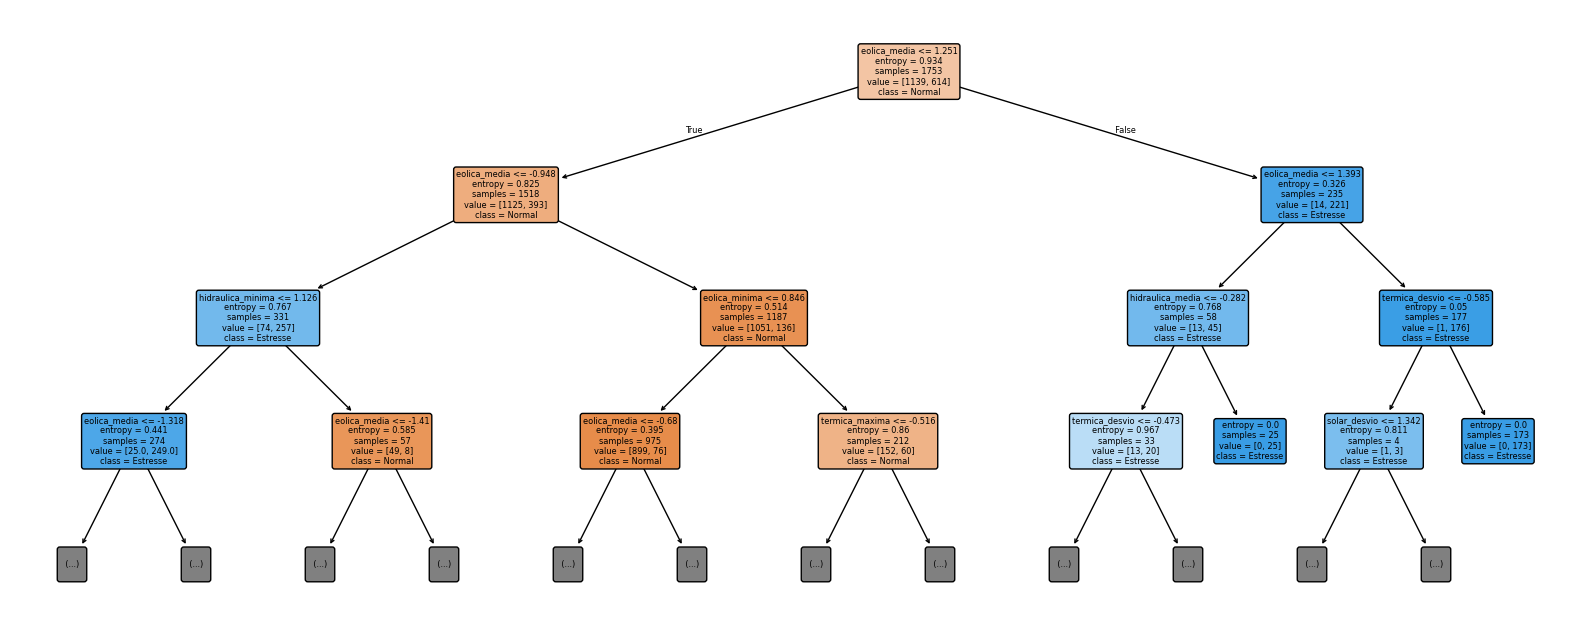

In [34]:
plt.figure(figsize=(20, 8))
tree.plot_tree(model_tree, 
               feature_names=X_train.columns.tolist(),
               class_names=['Normal', 'Estresse'],
               filled=True, 
               rounded=True,
               max_depth=3)
plt.show()

### 4.2 Regularização Minimal Cost-Complexity Pruning via validação cruzada:

In [35]:
path = model_tree.cost_complexity_pruning_path(X_train_scaled, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

print(f"Número de valores de alpha encontrados: {len(ccp_alphas)}")

Número de valores de alpha encontrados: 75


In [36]:
from sklearn.model_selection import cross_val_score

alpha_loop_values = []

for alpha in np.linspace(ccp_alphas.min(), ccp_alphas.max()):
    model_pruned = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)

    scores = cross_val_score(model_pruned, X_train_scaled, y_train, cv=5)
    alpha_loop_values.append([alpha, np.mean(scores)])

alpha_results = np.array(alpha_loop_values)

alphas_validos = alpha_results[alpha_results[:, 0] > 0.0005]
best_alpha = alphas_validos[np.argmax(alphas_validos[:, 1]), 0]


print(f"O Melhor Alpha encontrado foi (forçando): {best_alpha:.6f}")

O Melhor Alpha encontrado foi (forçando): 0.004063


In [37]:
tree_final = DecisionTreeClassifier(random_state=42, ccp_alpha=best_alpha)
tree_final.fit(X_train_scaled, y_train)

ein_final = 1 - tree_final.score(X_train_scaled, y_train)
eout_final = 1 - tree_final.score(X_test_scaled, y_test)

print(f"Novo Erro de Treinamento (Ein): {ein_final:.4f}")
print(f"Novo Erro de Teste (Eout): {eout_final:.4f}")

Novo Erro de Treinamento (Ein): 0.0616
Novo Erro de Teste (Eout): 0.0911


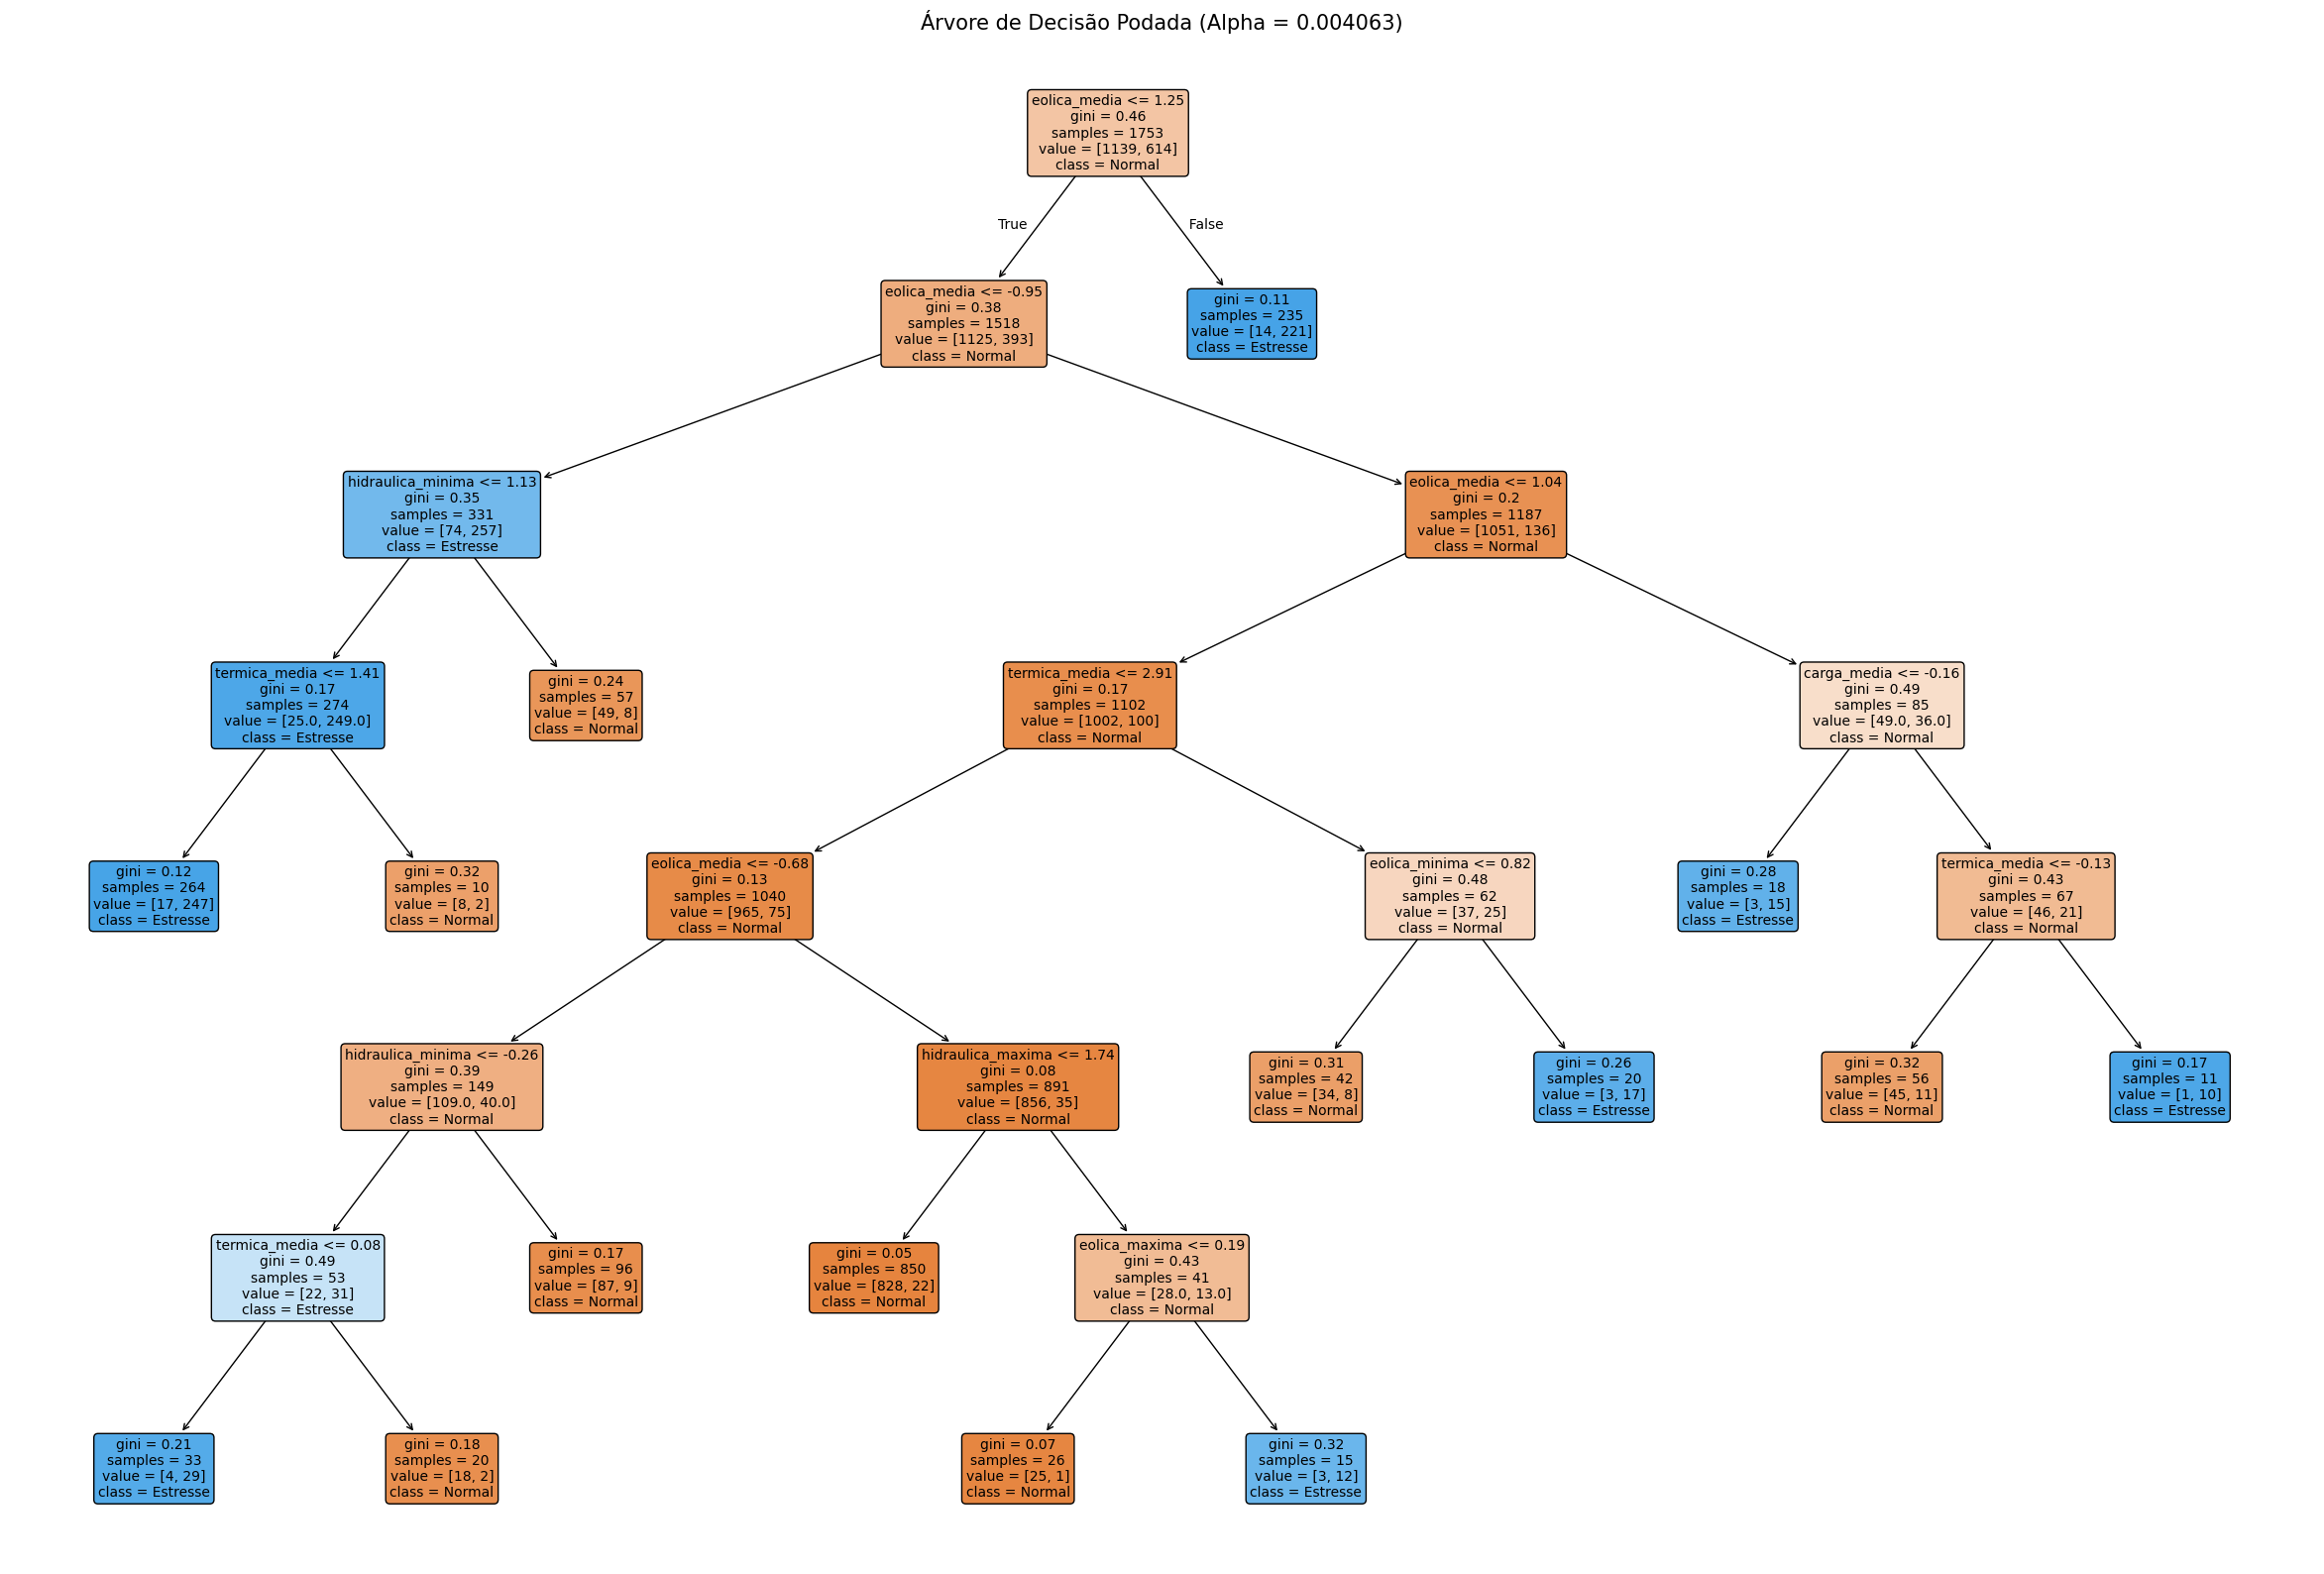

In [38]:
from sklearn.tree import plot_tree

plt.figure(figsize=(30, 20)) 

plot_tree(tree_final, 
          feature_names=X_train.columns.tolist(), 
          class_names=['Normal', 'Estresse'],
          filled=True,          
          rounded=True,         
          precision=2,         
          fontsize=10) 

plt.title(f"Árvore de Decisão Podada (Alpha = {best_alpha:.6f})", fontsize=15)
plt.show()

In [39]:
y_pred_tree = tree_final.predict(X_test_scaled)

print("=== Métricas de Qualidade (Árvore de Decisão Podada) ===")
print(f"Acurácia: {accuracy_score(y_test, y_pred_tree):.4f}\n")
print(classification_report(y_test, y_pred_tree, target_names=['Normal (0)', 'Estresse (1)']))


=== Métricas de Qualidade (Árvore de Decisão Podada) ===
Acurácia: 0.9089

              precision    recall  f1-score   support

  Normal (0)       0.92      0.94      0.93       285
Estresse (1)       0.88      0.86      0.87       154

    accuracy                           0.91       439
   macro avg       0.90      0.90      0.90       439
weighted avg       0.91      0.91      0.91       439



### 4.3 Usando Random Florest 

In [40]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train_scaled, y_train)

ein_rf = 1 - model_rf.score(X_train_scaled, y_train)
eout_rf = 1 - model_rf.score(X_test_scaled, y_test)

print(f"Erro de Treinamento da Floresta (Ein): {ein_rf:.4f}")
print(f"Erro de Teste da Floresta (Eout): {eout_rf:.4f}")

Erro de Treinamento da Floresta (Ein): 0.0000
Erro de Teste da Floresta (Eout): 0.0683


In [41]:
y_pred_rf = model_rf.predict(X_test_scaled)

print("=== Métricas de Qualidade (Random Forest) ===")
print(f"Acurácia: {accuracy_score(y_test, y_pred_rf):.4f}")
print(classification_report(y_test, y_pred_rf, target_names=['Normal (0)', 'Estresse (1)']))

=== Métricas de Qualidade (Random Forest) ===
Acurácia: 0.9317
              precision    recall  f1-score   support

  Normal (0)       0.95      0.95      0.95       285
Estresse (1)       0.90      0.90      0.90       154

    accuracy                           0.93       439
   macro avg       0.92      0.92      0.92       439
weighted avg       0.93      0.93      0.93       439



## 5. Arquitetura, Treinamento e Avaliação do SVM:

### 5.1 GridSearchCV com validação cruzada :


In [42]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

param_grid = [
    {
        'kernel': ['rbf'], 
        'C': [0.1, 1, 10, 100], 
        'gamma': ['scale', 'auto', 0.1, 1],
        'class_weight': ['balanced']
    },
    {
        'kernel': ['linear'], 
        'C': [0.1, 1, 10, 100],
        'class_weight': ['balanced']
    }
]

grid_search = GridSearchCV(SVC(random_state=42), param_grid, cv=5, scoring='accuracy', n_jobs=-1)

grid_search.fit(X_train_scaled, y_train)

best_svm = grid_search.best_estimator_
print(f"Melhores parâmetros encontrados: {grid_search.best_params_}\n")

Melhores parâmetros encontrados: {'C': 10, 'class_weight': 'balanced', 'gamma': 'scale', 'kernel': 'rbf'}



In [43]:
ein_svm = 1 - best_svm.score(X_train_scaled, y_train)
eout_svm = 1 - best_svm.score(X_test_scaled, y_test)

print(f"Erro de Treinamento SVM (Ein): {ein_svm:.4f}")
print(f"Erro de Teste SVM (Eout): {eout_svm:.4f}\n")

Erro de Treinamento SVM (Ein): 0.0120
Erro de Teste SVM (Eout): 0.0729



### 5.2 Avaliação Teórica do Erro de Teste ($E_out$):

In [44]:
n_support_vectors = sum(best_svm.n_support_)
n_total = len(X_train_scaled)
e_out_esperado = n_support_vectors / n_total

print(f"Número de Vetores de Suporte: {n_support_vectors}")
print(f"Eout esperado pela teoria: {e_out_esperado:.4f}")
print(f"Eout real obtido: {eout_svm:.4f}\n")

Número de Vetores de Suporte: 420
Eout esperado pela teoria: 0.2396
Eout real obtido: 0.0729



In [45]:
y_pred_svm = best_svm.predict(X_test_scaled)
print("=== Métricas de Qualidade (Melhor SVM) ===")
print(classification_report(y_test, y_pred_svm, target_names=['Normal (0)', 'Estresse (1)']))

=== Métricas de Qualidade (Melhor SVM) ===
              precision    recall  f1-score   support

  Normal (0)       0.97      0.92      0.94       285
Estresse (1)       0.86      0.95      0.90       154

    accuracy                           0.93       439
   macro avg       0.91      0.93      0.92       439
weighted avg       0.93      0.93      0.93       439



## 6. Conclusão:

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


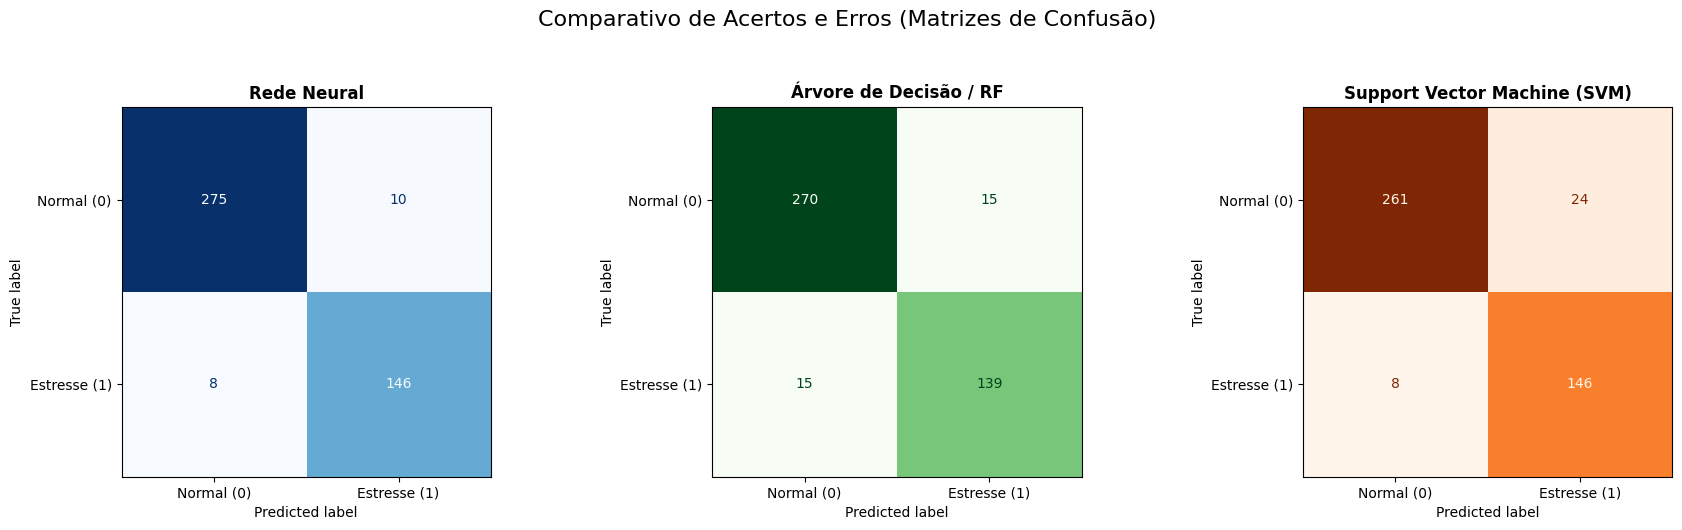

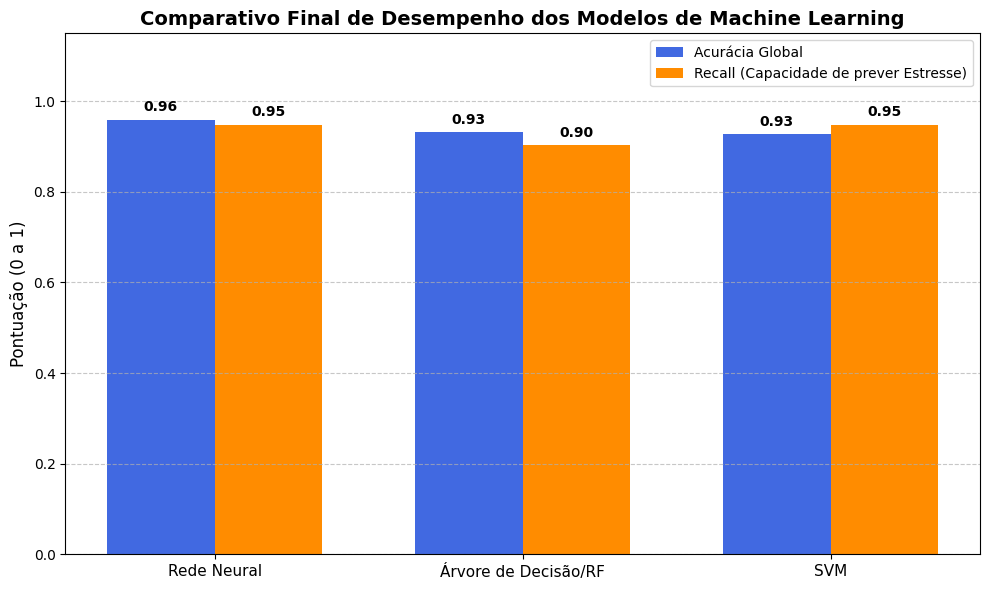

In [46]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, recall_score


y_pred_nn = (model_final.predict(X_test_scaled) > 0.5).astype(int)
y_pred_tree = model_rf.predict(X_test_scaled) 
y_pred_svm = best_svm.predict(X_test_scaled)

class_names = ['Normal (0)', 'Estresse (1)']


fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cm_nn = confusion_matrix(y_test, y_pred_nn)
disp_nn = ConfusionMatrixDisplay(confusion_matrix=cm_nn, display_labels=class_names)
disp_nn.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Rede Neural', fontweight='bold')

cm_tree = confusion_matrix(y_test, y_pred_tree)
disp_tree = ConfusionMatrixDisplay(confusion_matrix=cm_tree, display_labels=class_names)
disp_tree.plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title('Árvore de Decisão / RF', fontweight='bold')

cm_svm = confusion_matrix(y_test, y_pred_svm)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=class_names)
disp_svm.plot(ax=axes[2], cmap='Oranges', colorbar=False)
axes[2].set_title('Support Vector Machine (SVM)', fontweight='bold')

plt.suptitle("Comparativo de Acertos e Erros (Matrizes de Confusão)", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()



acc_nn, rec_nn = accuracy_score(y_test, y_pred_nn), recall_score(y_test, y_pred_nn)
acc_tree, rec_tree = accuracy_score(y_test, y_pred_tree), recall_score(y_test, y_pred_tree)
acc_svm, rec_svm = accuracy_score(y_test, y_pred_svm), recall_score(y_test, y_pred_svm)

labels = ['Rede Neural', 'Árvore de Decisão/RF', 'SVM']
acuracias = [acc_nn, acc_tree, acc_svm]
recalls = [rec_nn, rec_tree, rec_svm]

x = np.arange(len(labels))  
width = 0.35               

fig, ax = plt.subplots(figsize=(10, 6))

rects1 = ax.bar(x - width/2, acuracias, width, label='Acurácia Global', color='royalblue')
rects2 = ax.bar(x + width/2, recalls, width, label='Recall (Capacidade de prever Estresse)', color='darkorange')

ax.set_ylabel('Pontuação (0 a 1)', fontsize=12)
ax.set_title('Comparativo Final de Desempenho dos Modelos de Machine Learning', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylim(0, 1.15)
ax.legend(loc='upper right', frameon=True)
ax.grid(axis='y', linestyle='--', alpha=0.7)

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 4),  
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold')

autolabel(rects1)
autolabel(rects2)

fig.tight_layout()
plt.show()